In [1]:
# Load all tools and our trained model from S3

import pandas as pd
import numpy as np
import boto3
import io
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Your bucket
BUCKET_NAME = "churn-mlops-project-cherry"
s3 = boto3.client('s3')

def load_from_s3(bucket, key):
    obj = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(obj['Body'].read()))

# Load test data
X_test = load_from_s3(BUCKET_NAME, 'data/features/X_test.csv')
y_test = load_from_s3(BUCKET_NAME, 'data/features/y_test.csv').squeeze()

# Load the trained model
s3.download_file(BUCKET_NAME, 'models/latest/xgboost_churn_model.pkl', '/tmp/model.pkl')
model = joblib.load('/tmp/model.pkl')

print("✅ Model and data loaded!")
print(f"📊 Test data shape: {X_test.shape}")

✅ Model and data loaded!
📊 Test data shape: (228, 32)


In [2]:
# SHAP calculates how much each feature
# pushed the prediction up or down
# This takes about 1-2 minutes

print("⏳ Calculating SHAP values... please wait...")

# Create SHAP explainer for our XGBoost model
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for test data
shap_values = explainer.shap_values(X_test)

print("✅ SHAP values calculated!")
print(f"📊 SHAP values shape: {shap_values.shape}")

⏳ Calculating SHAP values... please wait...
✅ SHAP values calculated!
📊 SHAP values shape: (228, 32)


📊 Generating Feature Importance Chart...


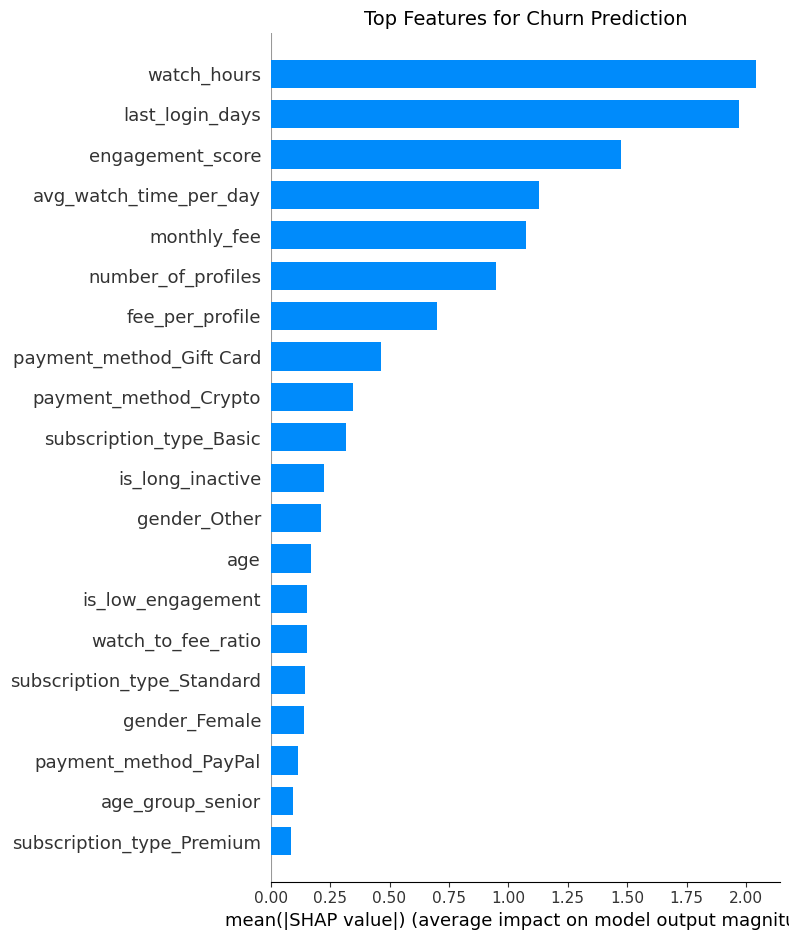

✅ Feature importance chart saved to S3!


In [3]:
# This chart shows which features matter MOST
# for predicting churn across ALL customers
# The longer the bar = the more important that feature is

print("📊 Generating Feature Importance Chart...")

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)
plt.title("Top Features for Churn Prediction", fontsize=14)
plt.tight_layout()

# Save to S3
plt.savefig('/tmp/feature_importance.png', dpi=150, bbox_inches='tight')
s3.upload_file('/tmp/feature_importance.png', BUCKET_NAME, 'reports/feature_importance.png')
plt.show()

print("✅ Feature importance chart saved to S3!")

📊 Generating SHAP Summary Dot Plot...


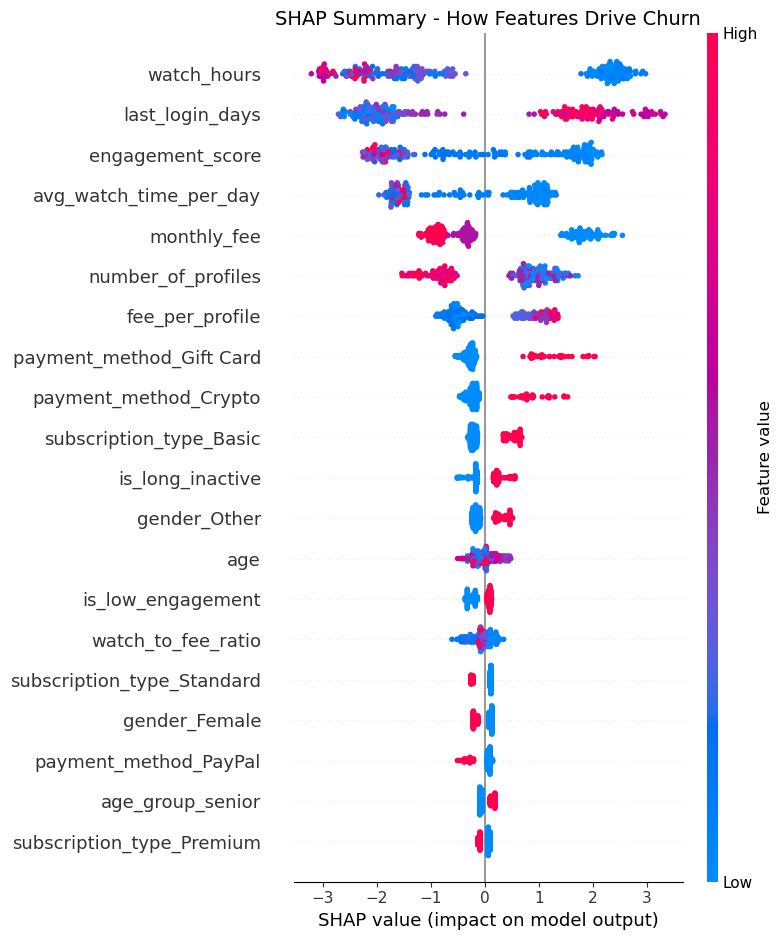

✅ SHAP summary plot saved to S3!


In [4]:
# This is the most powerful SHAP chart
# It shows EVERY customer as a dot
# Red dots = high feature value, Blue dots = low feature value
# Dots on the right = pushed prediction towards churn
# Dots on the left = pushed prediction away from churn

print("📊 Generating SHAP Summary Dot Plot...")

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)
plt.title("SHAP Summary - How Features Drive Churn", fontsize=14)
plt.tight_layout()

# Save to S3
plt.savefig('/tmp/shap_summary.png', dpi=150, bbox_inches='tight')
s3.upload_file('/tmp/shap_summary.png', BUCKET_NAME, 'reports/shap_summary.png')
plt.show()

print("✅ SHAP summary plot saved to S3!")

In [5]:
# This is the most impressive part
# We pick ONE customer and explain exactly
# WHY the model thinks they will churn
# This is what a business would actually use

# Pick the first customer in test set
customer_index = 0
single_customer = X_test.iloc[[customer_index]]
single_shap = shap_values[customer_index]

# Get prediction
prediction = model.predict_proba(single_customer)[0][1]
actual = y_test.iloc[customer_index]

print(f"👤 Customer Analysis:")
print(f"   Churn Probability: {prediction:.1%}")
print(f"   Actual outcome:    {'Churned ❌' if actual == 1 else 'Stayed ✅'}")
print(f"\n🔍 Top reasons for this prediction:")

# Show top 5 features driving this prediction
feature_impact = pd.DataFrame({
    'feature': X_test.columns,
    'shap_value': single_shap,
    'actual_value': single_customer.values[0]
})
feature_impact['abs_impact'] = abs(feature_impact['shap_value'])
feature_impact = feature_impact.sort_values('abs_impact', ascending=False).head(5)

for _, row in feature_impact.iterrows():
    direction = "⬆️ pushes TOWARDS churn" if row['shap_value'] > 0 else "⬇️ pushes AWAY from churn"
    print(f"   {row['feature']}: {row['actual_value']:.3f} → {direction}")

👤 Customer Analysis:
   Churn Probability: 99.7%
   Actual outcome:    Churned ❌

🔍 Top reasons for this prediction:
   watch_hours: -0.956 → ⬆️ pushes TOWARDS churn
   engagement_score: -0.366 → ⬆️ pushes TOWARDS churn
   last_login_days: -1.323 → ⬇️ pushes AWAY from churn
   number_of_profiles: -0.707 → ⬆️ pushes TOWARDS churn
   avg_watch_time_per_day: -0.415 → ⬆️ pushes TOWARDS churn


In [6]:
# Save a full SHAP report as CSV
# So the business team can look at it anytime

shap_df = pd.DataFrame(
    shap_values,
    columns=X_test.columns
)
shap_df['predicted_churn_prob'] = model.predict_proba(X_test)[:, 1]
shap_df['actual_churned'] = y_test.values

# Save to S3
csv_buffer = io.StringIO()
shap_df.to_csv(csv_buffer, index=False)
s3.put_object(
    Bucket=BUCKET_NAME,
    Key='reports/shap_values_report.csv',
    Body=csv_buffer.getvalue()
)

print("✅ Full SHAP report saved to S3!")
print(f"📁 Location: s3://{BUCKET_NAME}/reports/shap_values_report.csv")
print(f"\n🎉 Step 4 Complete!")
print(f"\nYour S3 reports folder now has:")
print(f"  📊 feature_importance.png  - which features matter most")
print(f"  📊 shap_summary.png        - how features drive churn")
print(f"  📊 shap_values_report.csv  - full explanation for every customer")

✅ Full SHAP report saved to S3!
📁 Location: s3://churn-mlops-project-cherry/reports/shap_values_report.csv

🎉 Step 4 Complete!

Your S3 reports folder now has:
  📊 feature_importance.png  - which features matter most
  📊 shap_summary.png        - how features drive churn
  📊 shap_values_report.csv  - full explanation for every customer
